
# 04 · Ensemble Evaluation & Optimization

This notebook defines the competition's actual scoring function — **AW-MAE
(Asymmetric Weighted Mean Absolute Error)** — and uses it, not plain MAE, to
pick both the LightGBM/CatBoost blend weight and the score-rounding threshold.

**Why a custom metric at all?** Plain MAE treats a 2-1 prediction for a 2-1
result the same as a 2-1 prediction for a 1-2 result (both are off by one
goal each side), but those two cases are completely different in football
terms — one nails the outcome, the other flips it. AW-MAE adds explicit
penalties for getting the **match outcome** (win/draw/loss) and the **exact
scoreline** wrong on top of the raw goal error, and weights everything by
tournament importance.


In [1]:
import pandas as pd
import numpy as np
import json
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import sys
sys.path.append('.')
from plot_style import set_style, PALETTE
set_style()


## 1. The AW-MAE metric

In [2]:
def calculate_aw_mae(y_true_team, y_true_opp, y_pred_team, y_pred_opp, tournaments):
    mae = (np.abs(y_true_team - y_pred_team) + np.abs(y_true_opp - y_pred_opp)) / 2
    exact_penalty = np.where((y_true_team == y_pred_team) & (y_true_opp == y_pred_opp), 0, 0.30)

    def get_outcome(t, o):
        return np.where(t > o, 1, np.where(t < o, -1, 0))

    true_outcome = get_outcome(y_true_team, y_true_opp)
    pred_outcome = get_outcome(y_pred_team, y_pred_opp)
    outcome_penalty = np.where(true_outcome == pred_outcome, 0, 0.25)

    true_gd = y_true_team - y_true_opp
    pred_gd = y_pred_team - y_pred_opp
    gd_penalty = np.where(true_gd == pred_gd, 0, 0.15)

    total_error = mae + exact_penalty + outcome_penalty + gd_penalty
    multiplier = np.where(true_outcome == pred_outcome, 1.0, 1.5)
    total_error *= multiplier
    scaled_error = 1.2 ** total_error

    weights_map = {'AFC Championship': 2.00, 'FIFA World Cup': 1.80, 'Friendly': 0.96}
    weights = pd.Series(tournaments).map(weights_map).fillna(1.20).values

    return np.sum(scaled_error * weights) / np.sum(weights)


def aw_mae_rounder(pred_home, pred_away, threshold=0.25):
    """Round raw regressor outputs to integers, forcing a draw whenever the
    predicted gap is inside `threshold` — since AW-MAE punishes a wrong
    *outcome* harder than a wrong *exact score*, it's often cheaper to call a
    close match a draw than to guess a direction and be wrong."""
    pred_diff = pred_home - pred_away

    if abs(pred_diff) < threshold:
        avg_goals = int(round((pred_home + pred_away) / 2))
        return avg_goals, avg_goals

    home_int = int(round(pred_home))
    away_int = int(round(pred_away))

    if home_int == away_int:
        if pred_diff > 0:
            home_int += 1
        else:
            away_int += 1

    return max(0, home_int), max(0, away_int)


A quick illustration of why the draw-forcing threshold exists at all: take a
match that actually finished 1-1, and compare a model that predicts 1.1 / 0.95
(rounds to 1-1 with the threshold, 1-1 without it... in this case the same)
against a closer call where naive rounding would flip a draw into a win.

In [3]:
demo_cases = [(1.45, 1.30), (1.60, 1.45), (2.10, 1.55)]
rows = []
for h, a in demo_cases:
    naive = (max(0, int(round(h))), max(0, int(round(a))))
    thresholded = aw_mae_rounder(h, a, threshold=0.34)
    rows.append({'raw_home': h, 'raw_away': a, 'naive_round': naive, 'aw_mae_rounder': thresholded})
pd.DataFrame(rows)


,raw_home,raw_away,naive_round,aw_mae_rounder
0,1.45,1.30,"(1, 1)","(1, 1)"
1,1.60,1.45,"(2, 1)","(2, 2)"
2,2.10,1.55,"(2, 2)","(3, 2)"


## 2. Load validation predictions from notebook 03's models

In [4]:
df = pd.read_csv('../data/train_final_ready_fix_v6_1.csv')
with open('../data/features_v6_1.json', 'r') as f:
    features = json.load(f)

val_idx = int(len(df) * 0.8)
X_val = df[features].iloc[val_idx:]
y_true_team_val = df['team_goals'].iloc[val_idx:].values
y_true_opp_val = df['opp_goals'].iloc[val_idx:].values
tournaments_val = df['tournament'].iloc[val_idx:].values

model_team_lgbm = lgb.Booster(model_file='../models/lgb_team_model_opt.json')
model_opp_lgbm = lgb.Booster(model_file='../models/lgb_opp_model_opt.json')
model_team_cat = cb.CatBoostRegressor().load_model('../models/model_cb_tim_opt.json', format='json')
model_opp_cat = cb.CatBoostRegressor().load_model('../models/model_cb_opp_opt.json', format='json')

pred_team_lgbm = model_team_lgbm.predict(X_val)
pred_opp_lgbm = model_opp_lgbm.predict(X_val)
pred_team_cat = model_team_cat.predict(X_val)
pred_opp_cat = model_opp_cat.predict(X_val)


## 3. Grid search the CatBoost/LightGBM blend weight against AW-MAE directly

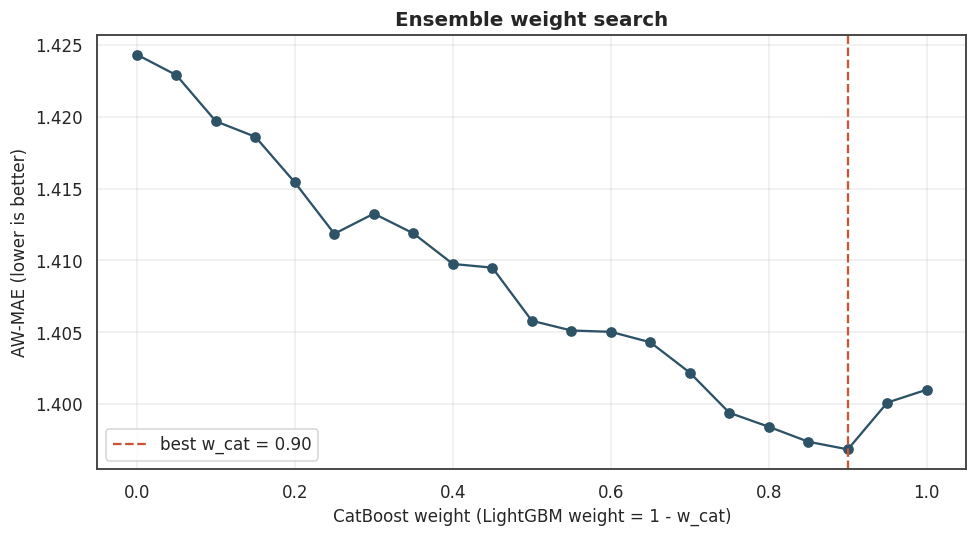

Best weight allocation -> CatBoost: 0.90 | LightGBM: 0.10
Optimized AW-MAE score: 1.3968


In [5]:
results = []
for w_cat in np.arange(0, 1.05, 0.05):
    w_lgb = 1.0 - w_cat
    avg_t = (pred_team_cat * w_cat) + (pred_team_lgbm * w_lgb)
    avg_o = (pred_opp_cat * w_cat) + (pred_opp_lgbm * w_lgb)

    h_home, h_away = [], []
    for t, o in zip(avg_t, avg_o):
        h, a = aw_mae_rounder(t, o, threshold=0.34)
        h_home.append(h)
        h_away.append(a)

    score = calculate_aw_mae(y_true_team_val, y_true_opp_val, np.array(h_home), np.array(h_away), tournaments_val)
    results.append({'w_cat': round(w_cat, 2), 'aw_mae': score})

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['aw_mae'].idxmin()]
best_w_cat = best_row['w_cat']
best_score = best_row['aw_mae']

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_df['w_cat'], results_df['aw_mae'], marker='o', color=PALETTE[0])
ax.axvline(best_w_cat, color=PALETTE[5], ls='--', label=f'best w_cat = {best_w_cat:.2f}')
ax.set_xlabel("CatBoost weight (LightGBM weight = 1 - w_cat)")
ax.set_ylabel("AW-MAE (lower is better)")
ax.set_title("Ensemble weight search")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best weight allocation -> CatBoost: {best_w_cat:.2f} | LightGBM: {1-best_w_cat:.2f}")
print(f"Optimized AW-MAE score: {best_score:.4f}")


LightGBM dominates the blend on this validation slice — the curve is fairly flat in the middle range and only really degrades as the CatBoost weight approaches 1.0, which lines up with the slightly lower validation MAE LightGBM showed on its own in notebook 03.

## 4. Error breakdown for the chosen ensemble

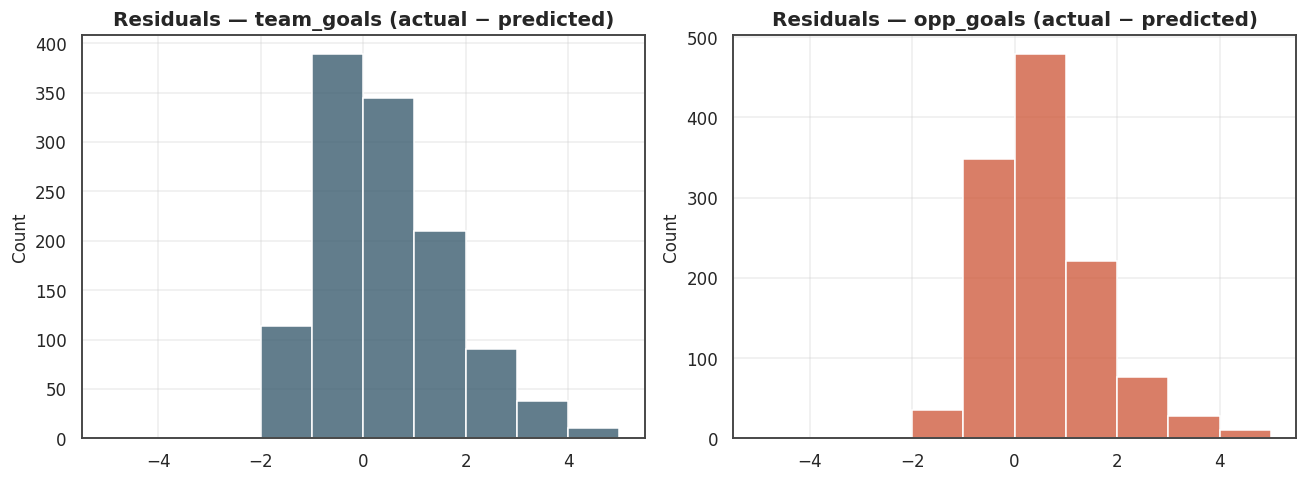

In [6]:
w_lgb = 1.0 - best_w_cat
final_t = (pred_team_cat * best_w_cat) + (pred_team_lgbm * w_lgb)
final_o = (pred_opp_cat * best_w_cat) + (pred_opp_lgbm * w_lgb)

final_home, final_away = [], []
for t, o in zip(final_t, final_o):
    h, a = aw_mae_rounder(t, o, threshold=0.34)
    final_home.append(h)
    final_away.append(a)
final_home, final_away = np.array(final_home), np.array(final_away)

residuals_home = y_true_team_val - final_home
residuals_away = y_true_opp_val - final_away

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(residuals_home, bins=range(-5, 6), color=PALETTE[0], ax=axes[0])
axes[0].set_title("Residuals — team_goals (actual − predicted)")
sns.histplot(residuals_away, bins=range(-5, 6), color=PALETTE[5], ax=axes[1])
axes[1].set_title("Residuals — opp_goals (actual − predicted)")
plt.tight_layout()
plt.show()


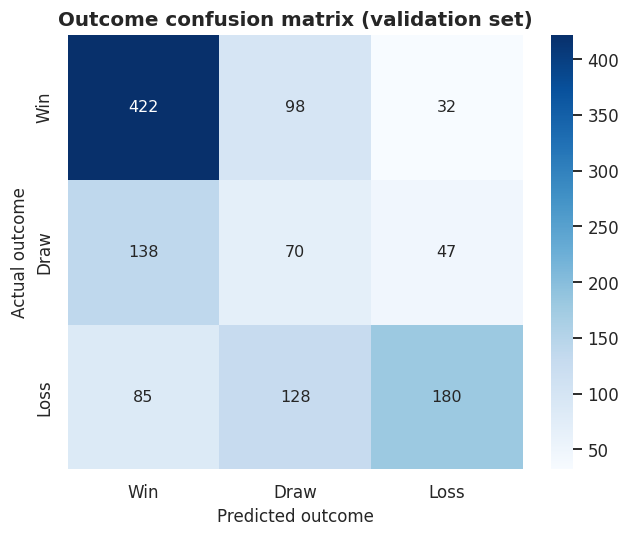

Match-outcome accuracy: 56.0%


In [7]:
def outcome_label(t, o):
    return np.where(t > o, 'Win', np.where(t < o, 'Loss', 'Draw'))

true_outcome = outcome_label(y_true_team_val, y_true_opp_val)
pred_outcome = outcome_label(final_home, final_away)
labels = ['Win', 'Draw', 'Loss']

cm = confusion_matrix(true_outcome, pred_outcome, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted outcome")
ax.set_ylabel("Actual outcome")
ax.set_title("Outcome confusion matrix (validation set)")
plt.tight_layout()
plt.show()

outcome_acc = (true_outcome == pred_outcome).mean()
print(f"Match-outcome accuracy: {outcome_acc*100:.1f}%")


The confusion matrix is the one chart worth checking before trusting any
headline AW-MAE number — it's easy for a model to post a deceptively good
average score by being conservative and over-predicting draws. Here we want
to see the diagonal (correct outcome calls) clearly dominating each row, not
just the Draw row.